####**Variational Autoencoder (VAE) on the MNIST dataset**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Load MNIST Dataset
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 343kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]


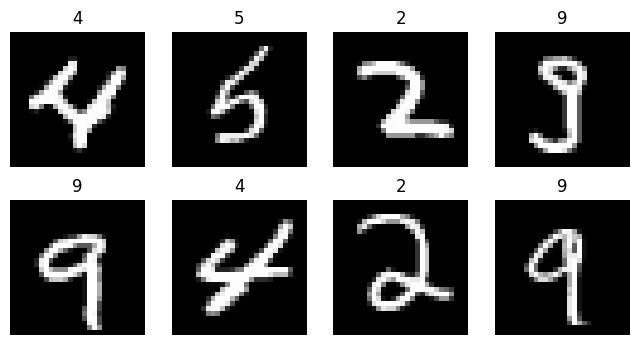

In [ ]:
# Visualize Dataset Samples
dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(8,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(labels[i].item())
    plt.axis('off')
plt.show()

####1. **Define VAE Model**
* Encoder → μ and log(σ²)
* Reparameterization Trick
* Decoder → reconstruction

In [ ]:
class VAE(nn.Module):

    def __init__(self):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, 20)
        self.fc_logvar = nn.Linear(400, 20)

        # Decoder
        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        h = self.relu(self.fc3(z))
        return self.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

####**2. Loss Function**
* VAE loss =
Reconstruction Loss + KL Divergence

In [ ]:
def loss_function(recon_x, x, mu, logvar):

    reconstruction_loss = nn.functional.binary_cross_entropy(
        recon_x, x, reduction='sum'
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return reconstruction_loss + kl_loss, reconstruction_loss, kl_loss

####**3. Initialize Model**

In [ ]:
model = VAE().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10

train_losses = []
recon_losses = []
kl_losses = []

####**4. Training Loop**

In [ ]:
for epoch in range(epochs):

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for data, _ in train_loader:

        data = data.view(-1, 784).to(device)

        optimizer.zero_grad()

        reconstruction, mu, logvar = model(data)

        loss, recon_loss, kl_loss = loss_function(
            reconstruction, data, mu, logvar
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    train_losses.append(total_loss/len(train_loader.dataset))
    recon_losses.append(total_recon/len(train_loader.dataset))
    kl_losses.append(total_kl/len(train_loader.dataset))

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Total Loss: {train_losses[-1]:.4f}")
    print(f"Reconstruction Loss: {recon_losses[-1]:.4f}")
    print(f"KL Divergence: {kl_losses[-1]:.4f}")

Epoch 1/10
Total Loss: 165.3162
Reconstruction Loss: 150.2193
KL Divergence: 15.0968
Epoch 2/10
Total Loss: 121.8684
Reconstruction Loss: 100.0433
KL Divergence: 21.8250
Epoch 3/10
Total Loss: 114.7125
Reconstruction Loss: 91.1205
KL Divergence: 23.5921
Epoch 4/10
Total Loss: 111.6838
Reconstruction Loss: 87.3425
KL Divergence: 24.3413
Epoch 5/10
Total Loss: 109.9176
Reconstruction Loss: 85.2262
KL Divergence: 24.6914
Epoch 6/10
Total Loss: 108.7657
Reconstruction Loss: 83.8510
KL Divergence: 24.9147
Epoch 7/10
Total Loss: 107.9222
Reconstruction Loss: 82.8900
KL Divergence: 25.0323
Epoch 8/10
Total Loss: 107.2839
Reconstruction Loss: 82.1378
KL Divergence: 25.1461
Epoch 9/10
Total Loss: 106.7429
Reconstruction Loss: 81.5475
KL Divergence: 25.1954
Epoch 10/10
Total Loss: 106.3795
Reconstruction Loss: 81.0966
KL Divergence: 25.2829


####**5. Loss Visualization**

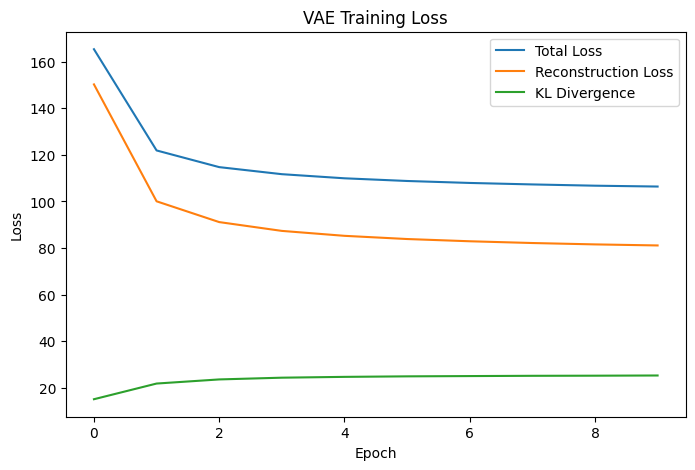

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Total Loss")
plt.plot(recon_losses, label="Reconstruction Loss")
plt.plot(kl_losses, label="KL Divergence")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.legend()

plt.show()

* The training results show that the total loss decreases significantly during the first few epochs and then gradually stabilizes, indicating that the VAE model is learning effectively. The reconstruction loss consistently decreases, meaning the decoder is improving its ability to reconstruct the input MNIST images. The KL divergence gradually increases and then stabilizes, which indicates that the latent space distribution is being regularized toward a Gaussian distribution. Overall, the loss curves demonstrate that the model is successfully balancing reconstruction quality and latent space regularization, leading to stable VAE training.

####**6. Reconstruction Visualization**

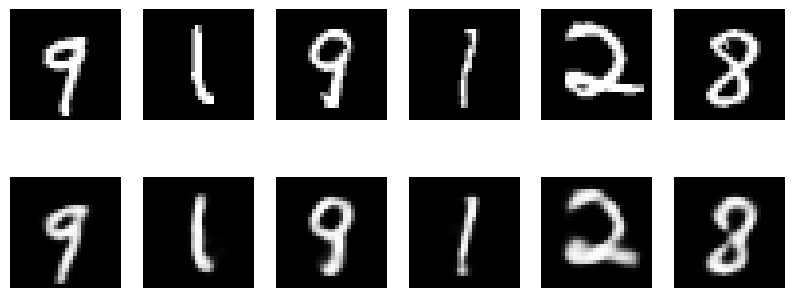

In [ ]:
model.eval()

with torch.no_grad():

    data, _ = next(iter(train_loader))
    data = data.view(-1,784).to(device)

    recon, _, _ = model(data)

    data = data.cpu().view(-1,28,28)
    recon = recon.cpu().view(-1,28,28)

plt.figure(figsize=(10,4))

for i in range(6):

    plt.subplot(2,6,i+1)
    plt.imshow(data[i], cmap='gray')
    plt.axis('off')

    plt.subplot(2,6,i+7)
    plt.imshow(recon[i], cmap='gray')
    plt.axis('off')

plt.show()

* The figure shows a comparison between the original MNIST images (top row) and the reconstructed images generated by the VAE decoder (bottom row). The reconstructed digits closely resemble the original inputs, indicating that the encoder successfully compresses the images into the latent space and the decoder effectively reconstructs them. Minor blurriness in the reconstructed images is expected in VAEs due to the probabilistic nature of the latent representation. Overall, the results demonstrate that the VAE has learned meaningful latent features of the handwritten digits.

####**7. Generate New Images from Latent Space**

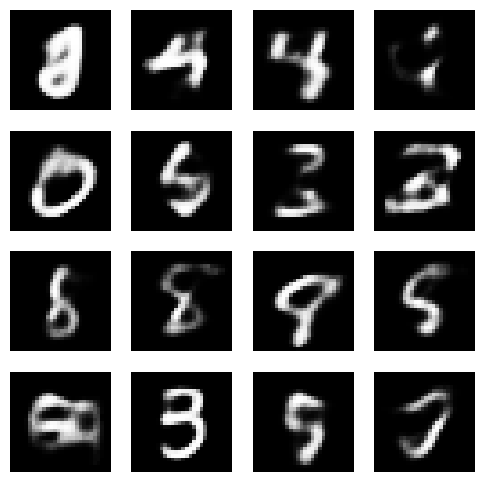

In [ ]:
with torch.no_grad():

    z = torch.randn(16,20).to(device)

    samples = model.decode(z).cpu()

samples = samples.view(-1,28,28)

plt.figure(figsize=(6,6))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(samples[i], cmap='gray')
    plt.axis('off')

plt.show()

* The figure shows new handwritten digit images generated by sampling random vectors from the VAE latent space and passing them through the decoder. Since these latent vectors are drawn from a Gaussian distribution, the decoder produces new digit-like images that were not present in the training dataset. The generated samples resemble handwritten digits, though some appear slightly blurry or imperfect, which is typical for Variational Autoencoders. This demonstrates that the model has learned a meaningful latent representation and can generate realistic variations of MNIST digits.

####**8. Latent Space Visualization**

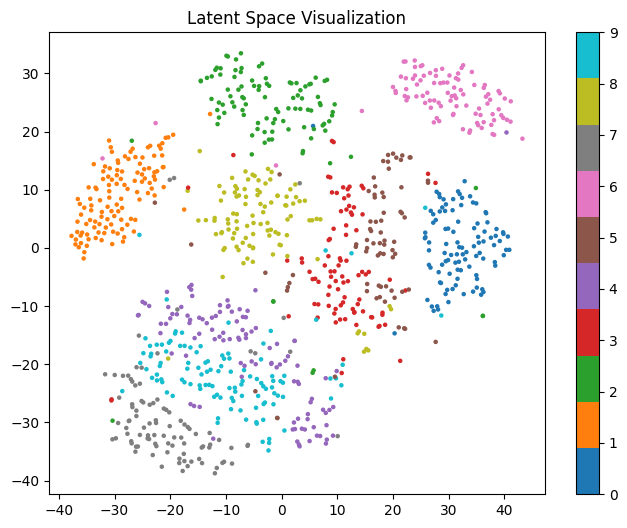

In [ ]:
from sklearn.manifold import TSNE

model.eval()

latent_vectors = []
labels_list = []

with torch.no_grad():

    for data, labels in train_loader:

        data = data.view(-1,784).to(device)

        mu, logvar = model.encode(data)

        latent_vectors.append(mu.cpu())
        labels_list.append(labels)

# convert list → tensor
latent_vectors = torch.cat(latent_vectors)
labels_list = torch.cat(labels_list)

# take only 1000 samples (to make TSNE fast)
latent_vectors = latent_vectors[:1000].numpy()
labels_list = labels_list[:1000].numpy()

tsne = TSNE(n_components=2)

latent_2d = tsne.fit_transform(latent_vectors)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    latent_2d[:,0],
    latent_2d[:,1],
    c=labels_list,
    cmap='tab10',
    s=5
)

plt.colorbar()
plt.title("Latent Space Visualization")
plt.show()

* The latent space visualization shows how the VAE encodes MNIST images into a lower-dimensional representation. Each point represents an image, and different colors correspond to different digit classes (0–9). The clusters formed in the plot indicate that the model has learned meaningful features, grouping similar digits close together in the latent space. This demonstrates that the VAE successfully captures the underlying structure of the handwritten digits.